# CE 冷却效率 — 深度分析
> Hydraulic Systems Dataset | 2205 cycles x 60s | Cooling Efficiency (virtual sensor) %

CE = Cooling Efficiency, 通过物理传感器计算得到的虚拟冷却效率指标.
与 VS1 振动传感器对比分析, 验证虚拟传感器的故障诊断能力.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import signal, stats as sp_stats
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.feature_selection import f_classif
from tslearn.clustering import KShape
from tslearn.metrics import cdist_dtw
import os, warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")

In [2]:
DATA_DIR = r'd:/for HS/dataset'

ce = pd.read_csv(os.path.join(DATA_DIR, 'CE.txt'), sep='\t', header=None)
profile = pd.read_csv(os.path.join(DATA_DIR, 'profile.txt'), sep='\t', header=None)
profile.columns = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

print(f'CE shape: {ce.shape} — {ce.shape[0]} cycles x {ce.shape[1]} seconds')
print(f'CE value range: {ce.values.min():.2f}% ~ {ce.values.max():.2f}%')
print(f'Per-cycle mean range: {ce.mean(axis=1).min():.2f}% ~ {ce.mean(axis=1).max():.2f}%')
print(f'\nProfile columns: {list(profile.columns)}')
print(f'\nCE by Cooler state:')
for val, label in [(100, 'Healthy'), (20, 'Reduced'), (3, 'Near-failure')]:
    mask = profile['Cooler'] == val
    ce_mean = ce[mask].mean(axis=1).mean()
    ce_std  = ce[mask].mean(axis=1).std()
    print(f'  Cooler={val:>3}% ({label:<12}): CE = {ce_mean:.2f}% +/- {ce_std:.2f}%  (n={mask.sum()})')
print(f'\nCE by other faults (cycle-mean level):')
for col in ['Valve', 'Pump_Leakage', 'Accumulator']:
    print(f'  {col}:')
    for val in sorted(profile[col].unique()):
        mask = profile[col] == val
        print(f'    {col}={val}: CE={ce[mask].mean(axis=1).mean():.2f}% (n={mask.sum()})')

CE shape: (2205, 60) — 2205 cycles x 60 seconds
CE value range: 17.04% ~ 48.78%
Per-cycle mean range: 17.56% ~ 47.90%

Profile columns: ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

CE by Cooler state:
  Cooler=100% (Healthy     ): CE = 46.93% +/- 0.56%  (n=741)
  Cooler= 20% (Reduced     ): CE = 27.20% +/- 0.60%  (n=732)
  Cooler=  3% (Near-failure): CE = 19.57% +/- 1.05%  (n=732)

CE by other faults (cycle-mean level):
  Valve:
    Valve=73: CE=31.32% (n=360)
    Valve=80: CE=31.30% (n=360)
    Valve=90: CE=31.36% (n=360)
    Valve=100: CE=31.27% (n=1125)
  Pump_Leakage:
    Pump_Leakage=0: CE=31.32% (n=1221)
    Pump_Leakage=1: CE=31.22% (n=492)
    Pump_Leakage=2: CE=31.33% (n=492)
  Accumulator:
    Accumulator=90: CE=33.97% (n=808)
    Accumulator=100: CE=31.17% (n=399)
    Accumulator=115: CE=31.43% (n=399)
    Accumulator=130: CE=27.68% (n=599)


---
## 模块 1：CE-Cooler 剂量响应曲线

**问题**：CE 和 Cooler 状态的映射关系有多紧密？CE 能否作为 Cooler 健康的单变量代理指标？

In [3]:
cycle_ce_mean = ce.mean(axis=1).values
cycle_ce_std  = ce.std(axis=1).values
cooler_vals = profile['Cooler'].values

# Build per-Cooler-state CE distributions
cooler_states = [100, 20, 3]
cooler_labels_map = {100: 'Healthy 100%', 20: 'Reduced 20%', 3: 'Near-failure 3%'}

ce_by_cooler = {}
for state in cooler_states:
    mask = cooler_vals == state
    ce_by_cooler[state] = {
        'mean': cycle_ce_mean[mask].mean(),
        'std':  cycle_ce_mean[mask].std(),
        'min':  cycle_ce_mean[mask].min(),
        'max':  cycle_ce_mean[mask].max(),
        'data': cycle_ce_mean[mask]
    }
    print(f'Cooler={state:>3}%: CE mean={ce_by_cooler[state]["mean"]:.2f}%, '
          f'std={ce_by_cooler[state]["std"]:.2f}%, '
          f'range=[{ce_by_cooler[state]["min"]:.1f}, {ce_by_cooler[state]["max"]:.1f}]%')

# Separation metric: Cohen's d between adjacent states
for s1, s2 in [(100, 20), (20, 3)]:
    d = (ce_by_cooler[s1]['mean'] - ce_by_cooler[s2]['mean']) / \
        np.sqrt((ce_by_cooler[s1]['std']**2 + ce_by_cooler[s2]['std']**2) / 2)
    print(f'Cohen d (Cooler {s1}% vs {s2}%): {d:.1f}')

Cooler=100%: CE mean=46.93%, std=0.56%, range=[35.7, 47.9]%
Cooler= 20%: CE mean=27.20%, std=0.60%, range=[22.8, 28.3]%
Cooler=  3%: CE mean=19.57%, std=1.05%, range=[17.6, 39.6]%
Cohen d (Cooler 100% vs 20%): 34.2
Cohen d (Cooler 20% vs 3%): 8.9


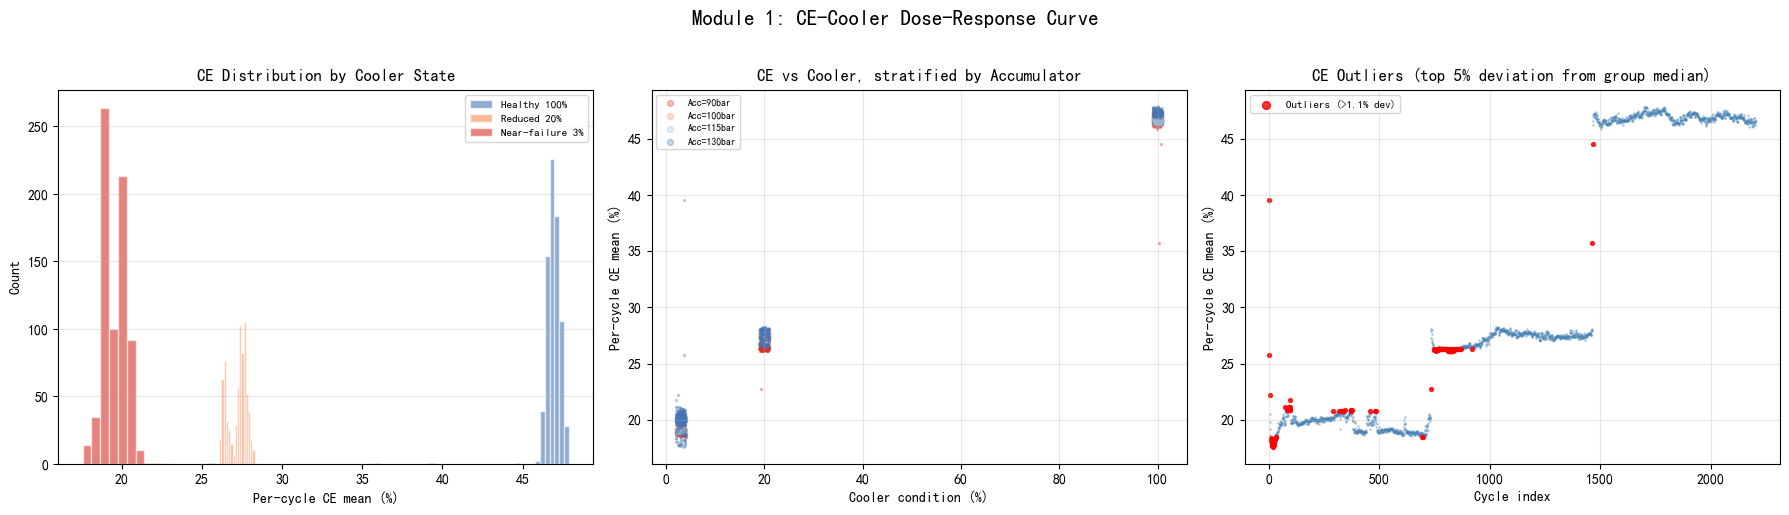

Outlier cycles: 111 / 2205 (5.0%)
  — cycles where CE deviates >1.1% from its Cooler-group median


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CE distribution by Cooler state
colors_cooler = {100: '#4575b4', 20: '#fc8d59', 3: '#d73027'}
for state in cooler_states:
    axes[0].hist(ce_by_cooler[state]['data'], bins=40, alpha=0.6,
        color=colors_cooler[state], label=cooler_labels_map[state], edgecolor='white')
axes[0].set_xlabel('Per-cycle CE mean (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('CE Distribution by Cooler State', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: CE vs Cooler with Accumulator stratification
acc_states = sorted(profile['Accumulator'].unique())
acc_colors = {130: '#4575b4', 115: '#91bfdb', 100: '#fc8d59', 90: '#d73027'}
for acc in acc_states:
    mask = profile['Accumulator'] == acc
    axes[1].scatter(cooler_vals[mask] + np.random.uniform(-1, 1, mask.sum()),
        cycle_ce_mean[mask], s=2, alpha=0.3, c=acc_colors[acc],
        label=f'Acc={acc}bar', rasterized=True)
axes[1].set_xlabel('Cooler condition (%)')
axes[1].set_ylabel('Per-cycle CE mean (%)')
axes[1].set_title('CE vs Cooler, stratified by Accumulator', fontsize=12)
axes[1].legend(fontsize=7, markerscale=3)
axes[1].grid(True, alpha=0.3)

# Plot 3: Outlier detection — residuals from median CE per Cooler group
ce_expected = np.zeros_like(cycle_ce_mean)
for state in cooler_states:
    mask = cooler_vals == state
    ce_expected[mask] = np.median(cycle_ce_mean[mask])
residuals = np.abs(cycle_ce_mean - ce_expected)
threshold = np.percentile(residuals, 95)
outlier_mask = residuals > threshold
axes[2].scatter(range(len(ce)), cycle_ce_mean, s=1, alpha=0.3, c='steelblue', rasterized=True)
axes[2].scatter(np.where(outlier_mask)[0], cycle_ce_mean[outlier_mask],
    s=8, c='red', alpha=0.8, label=f'Outliers (>{threshold:.1f}% dev)')
axes[2].set_xlabel('Cycle index')
axes[2].set_ylabel('Per-cycle CE mean (%)')
axes[2].set_title(f'CE Outliers (top 5% deviation from group median)', fontsize=12)
axes[2].legend(fontsize=8, markerscale=2)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Module 1: CE-Cooler Dose-Response Curve', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f'Outlier cycles: {outlier_mask.sum()} / {len(ce)} ({outlier_mask.sum()/len(ce)*100:.1f}%)')
print(f'  — cycles where CE deviates >{threshold:.1f}% from its Cooler-group median')

---
## 模块 2：周期内效率动力学

**问题**：60 秒内 CE 曲线形态如何随 Cooler 退化而变化？冷却效率下降集中在周期的哪个阶段？

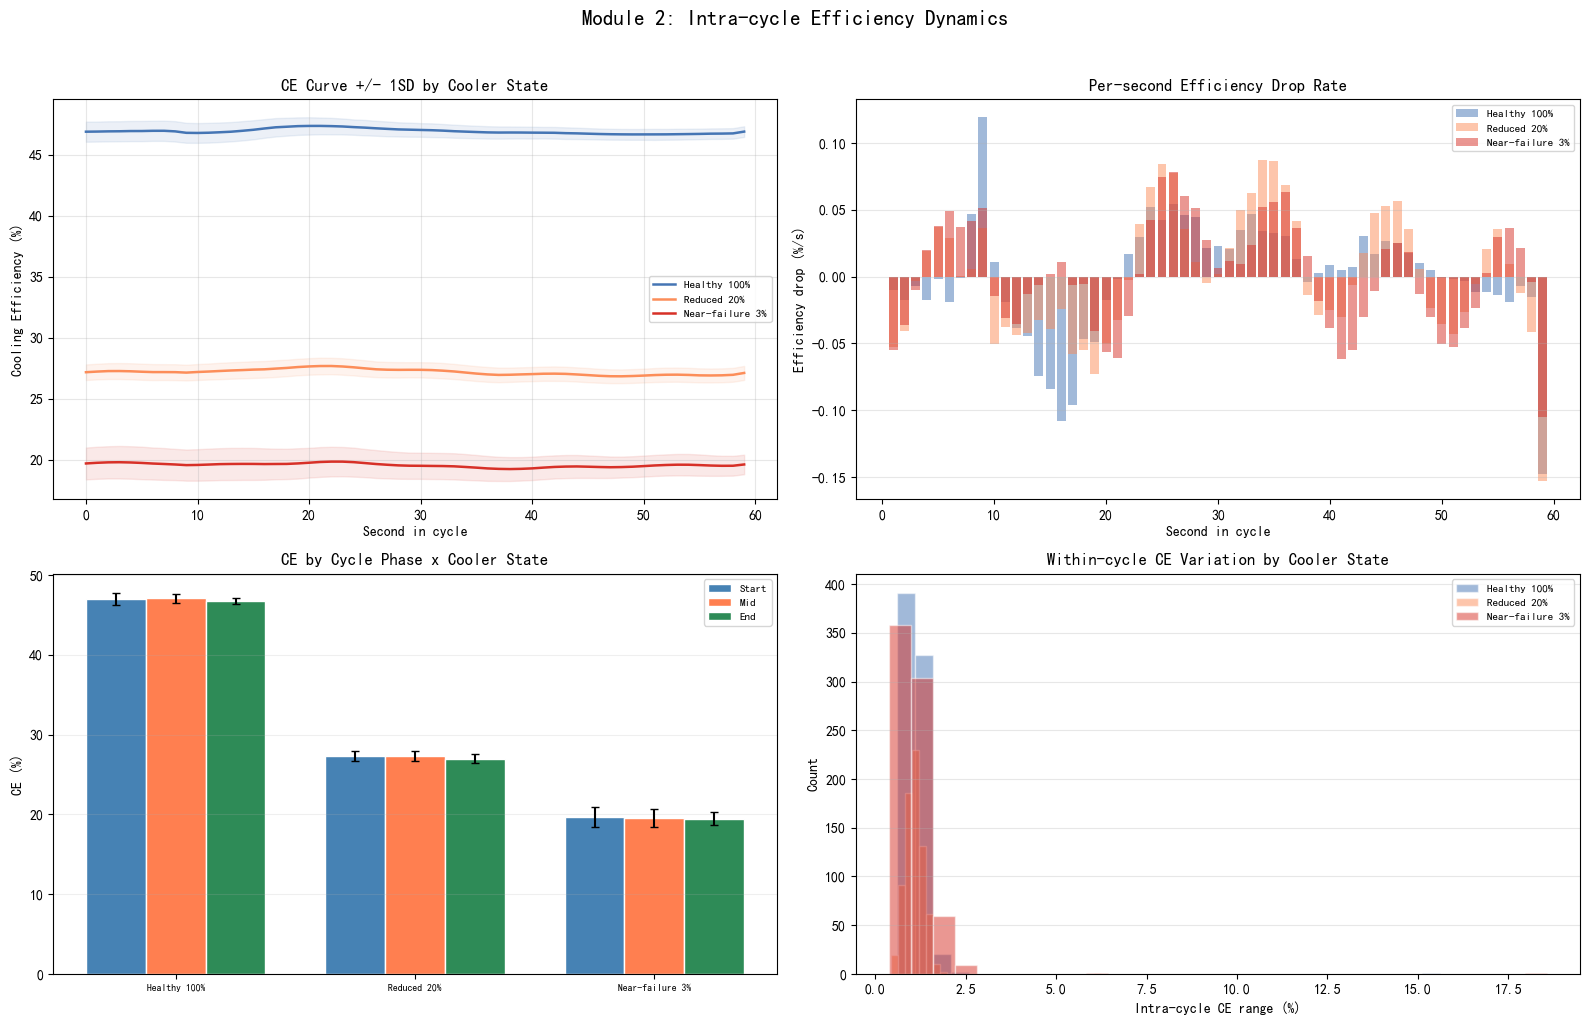

Phase analysis (CE % per segment):
  Cooler=100%:
    Start (0-20s): 46.98%
    Mid (20-40s): 47.07%
    End (40-60s): 46.74%
  Cooler=20%:
    Start (0-20s): 27.30%
    Mid (20-40s): 27.34%
    End (40-60s): 26.96%
  Cooler=3%:
    Start (0-20s): 19.68%
    Mid (20-40s): 19.55%
    End (40-60s): 19.48%


In [5]:
time = np.arange(60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Mean curve +/- 1SD per Cooler state
for state in cooler_states:
    mask = cooler_vals == state
    group = ce[mask]
    mean_curve = group.mean(axis=0)
    std_curve  = group.std(axis=0)
    axes[0,0].plot(time, mean_curve, color=colors_cooler[state], linewidth=1.8,
        label=cooler_labels_map[state])
    axes[0,0].fill_between(time, mean_curve-std_curve, mean_curve+std_curve,
        color=colors_cooler[state], alpha=0.1)
axes[0,0].set_title('CE Curve +/- 1SD by Cooler State', fontsize=12)
axes[0,0].set_xlabel('Second in cycle')
axes[0,0].set_ylabel('Cooling Efficiency (%)')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Per-second decay rate (negative gradient)
for state in cooler_states:
    mask = cooler_vals == state
    group = ce[mask]
    mean_curve = group.mean(axis=0).values
    decay = -np.diff(mean_curve)
    axes[0,1].bar(time[1:], decay, alpha=0.5, color=colors_cooler[state],
        label=cooler_labels_map[state], width=0.8)
axes[0,1].set_title('Per-second Efficiency Drop Rate', fontsize=12)
axes[0,1].set_xlabel('Second in cycle')
axes[0,1].set_ylabel('Efficiency drop (%/s)')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Phase analysis — 3 segments
segments = [(0, 20, 'Start'), (20, 40, 'Mid'), (40, 60, 'End')]
x = np.arange(len(cooler_states))
width = 0.25
seg_colors = ['steelblue', 'coral', 'seagreen']
for si, (start, end, seg_name) in enumerate(segments):
    means = []
    errs = []
    for state in cooler_states:
        mask = cooler_vals == state
        seg_data = ce[mask].iloc[:, start:end].values
        means.append(seg_data.mean())
        errs.append(np.std([row.mean() for row in ce[mask].iloc[:, start:end].values]))
    axes[1,0].bar(x + si*width, means, width, color=seg_colors[si],
        edgecolor='white', label=seg_name, yerr=errs, capsize=3)
axes[1,0].set_xticks(x + width)
axes[1,0].set_xticklabels([cooler_labels_map[s] for s in cooler_states], fontsize=7)
axes[1,0].set_ylabel('CE (%)')
axes[1,0].set_title('CE by Cycle Phase x Cooler State', fontsize=12)
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.2, axis='y')

# Plot 4: CE range (max-min) per cycle as function of Cooler
ce_range = ce.max(axis=1) - ce.min(axis=1)
for state in cooler_states:
    mask = cooler_vals == state
    axes[1,1].hist(ce_range[mask], bins=30, alpha=0.5,
        color=colors_cooler[state], label=cooler_labels_map[state], edgecolor='white')
axes[1,1].set_xlabel('Intra-cycle CE range (%)')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Within-cycle CE Variation by Cooler State', fontsize=12)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Module 2: Intra-cycle Efficiency Dynamics', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Key stats
print('Phase analysis (CE % per segment):')
for state in cooler_states:
    mask = cooler_vals == state
    print(f'  Cooler={state}%:')
    for start, end, seg_name in segments:
        seg_mean = ce[mask].iloc[:, start:end].values.mean()
        print(f'    {seg_name} ({start}-{end}s): {seg_mean:.2f}%')

---
## 模块 3：PCA 降维 + 逐秒信息密度

**问题**：CE 的 60 维数据本质维度是多少？和 VS1（PC1=74%）相比如何？

In [6]:
# PCA on CE
pca_ce = PCA(n_components=5)
pca_ce_scores = pca_ce.fit_transform(ce.values)

print('CE PCA Explained Variance:')
for i, (evr, cum) in enumerate(zip(pca_ce.explained_variance_ratio_, np.cumsum(pca_ce.explained_variance_ratio_))):
    bar = chr(0x2588) * int(evr * 50)
    print(f'  PC{i+1}: {evr:5.1%} {bar}  (cumulative {cum:.1%})')
print(f'\nCE intrinsic dimension: PC1 explains {pca_ce.explained_variance_ratio_[0]:.1%} variance')

# F-scores per second for CE vs Cooler
f_scores_ce = np.zeros(60)
y = profile['Cooler'].values
for t in range(60):
    X_t = ce.iloc[:, t].values.reshape(-1, 1)
    f_scores_ce[t], _ = f_classif(X_t, y)

top5_ce = sorted(np.argsort(f_scores_ce)[-5:])
print(f'\nCE top-5 discriminative seconds: {top5_ce}')
f_vals = [f_scores_ce[t] for t in top5_ce]
print(f'  F-values: {[round(v) for v in f_vals]}')

CE PCA Explained Variance:
  PC1: 99.9% █████████████████████████████████████████████████  (cumulative 99.9%)
  PC2:  0.0%   (cumulative 100.0%)
  PC3:  0.0%   (cumulative 100.0%)
  PC4:  0.0%   (cumulative 100.0%)
  PC5:  0.0%   (cumulative 100.0%)

CE intrinsic dimension: PC1 explains 99.9% variance

CE top-5 discriminative seconds: [np.int64(48), np.int64(56), np.int64(57), np.int64(58), np.int64(59)]
  F-values: [352264, 357553, 369558, 375749, 379179]


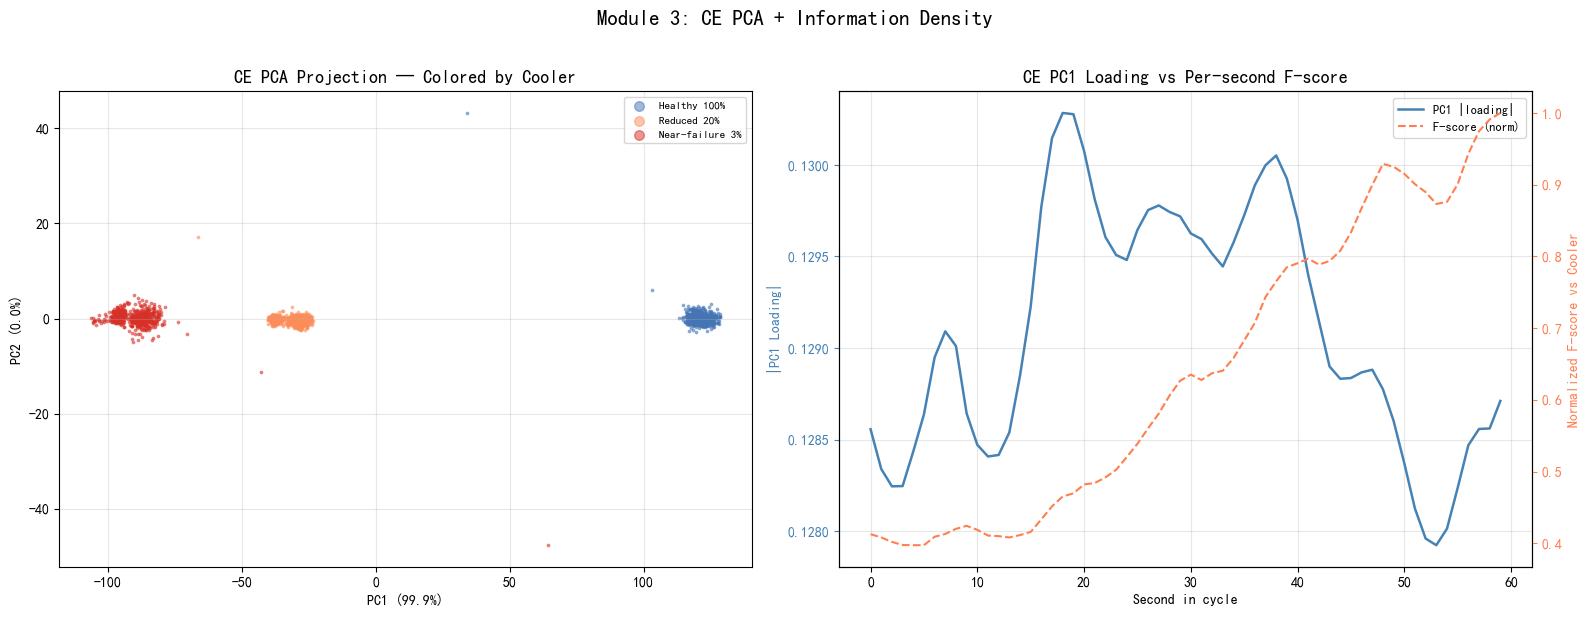

Note: PC1 loading and F-score both highlight which seconds carry the most Cooler-discriminative information.
CE vs VS1 comparison will be shown in Module 5.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for state in cooler_states:
    mask = cooler_vals == state
    axes[0].scatter(pca_ce_scores[mask, 0], pca_ce_scores[mask, 1],
        c=colors_cooler[state], s=3, alpha=0.5, label=cooler_labels_map[state], rasterized=True)
axes[0].set_xlabel(f'PC1 ({pca_ce.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_ce.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('CE PCA Projection — Colored by Cooler', fontsize=13)
axes[0].legend(fontsize=8, markerscale=4)
axes[0].grid(True, alpha=0.3)

# PC1 loading + F-score overlay
ax2 = axes[1]
ax2.plot(range(60), np.abs(pca_ce.components_[0]), 'steelblue', linewidth=1.8, label='PC1 |loading|')
ax2.set_xlabel('Second in cycle')
ax2.set_ylabel('|PC1 Loading|', color='steelblue')
ax2.tick_params(axis='y', colors='steelblue')
ax2_twin = ax2.twinx()
ax2_twin.plot(range(60), f_scores_ce / f_scores_ce.max(), 'coral', linewidth=1.5, linestyle='--', label='F-score (norm)')
ax2_twin.set_ylabel('Normalized F-score vs Cooler', color='coral')
ax2_twin.tick_params(axis='y', colors='coral')
ax2.set_title('CE PC1 Loading vs Per-second F-score', fontsize=13)
ax2.grid(True, alpha=0.3)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle('Module 3: CE PCA + Information Density', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Note: PC1 loading and F-score both highlight which seconds carry the most Cooler-discriminative information.')
print(f'CE vs VS1 comparison will be shown in Module 5.')

---
## 模块 4：状态切换响应（精简）

**问题**：Cooler 状态切换时，CE 是瞬时跳变还是逐渐响应？

> 仅 2 个切换事件 — 结论来自定量统计而非可视化。

In [8]:
transitions = np.where(np.diff(cooler_vals) != 0)[0]
print(f'Cooler state transitions: {len(transitions)} events')

# Analyze CE change at each transition
pre_windows = [5, 10, 20]
post_windows = [5, 10, 20]
print('CE jump at Cooler transitions:')
for pw in pre_windows:
    jumps = []
    for tp in transitions:
        if tp >= pw and tp + pw < len(ce):
            ce_before = cycle_ce_mean[tp-pw:tp].mean()
            ce_after  = cycle_ce_mean[tp:tp+pw].mean()
            jumps.append(ce_after - ce_before)
    if jumps:
        print(f'  +/- {pw} cycles: mean jump = {np.mean(jumps):+.2f}%, '
              f'std = {np.std(jumps):.2f}%, n = {len(jumps)}')

Cooler state transitions: 2 events
CE jump at Cooler transitions:
  +/- 5 cycles: mean jump = +8.72%, std = 3.67%, n = 2
  +/- 10 cycles: mean jump = +11.04%, std = 4.95%, n = 2
  +/- 20 cycles: mean jump = +12.17%, std = 5.56%, n = 2


---
## 模块 5：K-Shape 聚类 + 虚拟传感器验证

**问题**：不依赖标签，CE 曲线形态能否自动识别 Cooler 状态？CE 在这方面比 VS1 更强吗？

In [10]:
series_ce = ce.values.astype(np.float64)
cooler_true = profile['Cooler'].values

print('Running K-Shape on CE (2205 cycles)...')
ks3 = KShape(n_clusters=3, random_state=42, n_init=3, max_iter=50, verbose=False)
labels_ce_3 = ks3.fit_predict(series_ce)
ari_ce_3 = adjusted_rand_score(cooler_true, labels_ce_3)
print(f'CE K-Shape (3 clusters) vs Cooler: ARI = {ari_ce_3:.4f}')

ks4 = KShape(n_clusters=4, random_state=42, n_init=3, max_iter=50, verbose=False)
labels_ce_4 = ks4.fit_predict(series_ce)
ari_ce_4 = adjusted_rand_score(cooler_true, labels_ce_4)
print(f'CE K-Shape (4 clusters) vs Cooler: ARI = {ari_ce_4:.4f}')

# Cluster composition
ct3 = pd.crosstab(pd.Series(labels_ce_3, name='Cluster'), pd.Series(cooler_true, name='Cooler'), normalize='columns')
print('CE K-Shape (3-cluster) normalized confusion:')
print(ct3.round(3))

Running K-Shape on CE (2205 cycles)...


CE K-Shape (3 clusters) vs Cooler: ARI = 0.0000


CE K-Shape (4 clusters) vs Cooler: ARI = 0.0001
CE K-Shape (3-cluster) normalized confusion:
Cooler   3    20   100
Cluster               
2        1.0  1.0  1.0


In [11]:
# Load VS1 for comparison
vs1 = pd.read_csv(os.path.join(DATA_DIR, 'VS1.txt'), sep='\t', header=None)
series_vs1 = vs1.values.astype(np.float64)

print(f'VS1 shape: {series_vs1.shape}')

# K-Shape on VS1
ks_vs1_3 = KShape(n_clusters=3, random_state=42, n_init=3, max_iter=50, verbose=False)
labels_vs1_3 = ks_vs1_3.fit_predict(series_vs1)
ari_vs1_3 = adjusted_rand_score(cooler_true, labels_vs1_3)
print(f'VS1 K-Shape (3 clusters) vs Cooler: ARI = {ari_vs1_3:.4f}')

ks_vs1_4 = KShape(n_clusters=4, random_state=42, n_init=3, max_iter=50, verbose=False)
labels_vs1_4 = ks_vs1_4.fit_predict(series_vs1)
ari_vs1_4 = adjusted_rand_score(cooler_true, labels_vs1_4)
print(f'VS1 K-Shape (4 clusters) vs Cooler: ARI = {ari_vs1_4:.4f}')

# Also compare PCA compactness
pca_vs1 = PCA(n_components=5)
pca_vs1.fit(series_vs1)
print(f'CE  PC1 variance: {pca_ce.explained_variance_ratio_[0]:.1%}')
print(f'VS1 PC1 variance: {pca_vs1.explained_variance_ratio_[0]:.1%}')

VS1 shape: (2205, 60)


VS1 K-Shape (3 clusters) vs Cooler: ARI = 0.0000


VS1 K-Shape (4 clusters) vs Cooler: ARI = 0.0000
CE  PC1 variance: 99.9%
VS1 PC1 variance: 74.3%


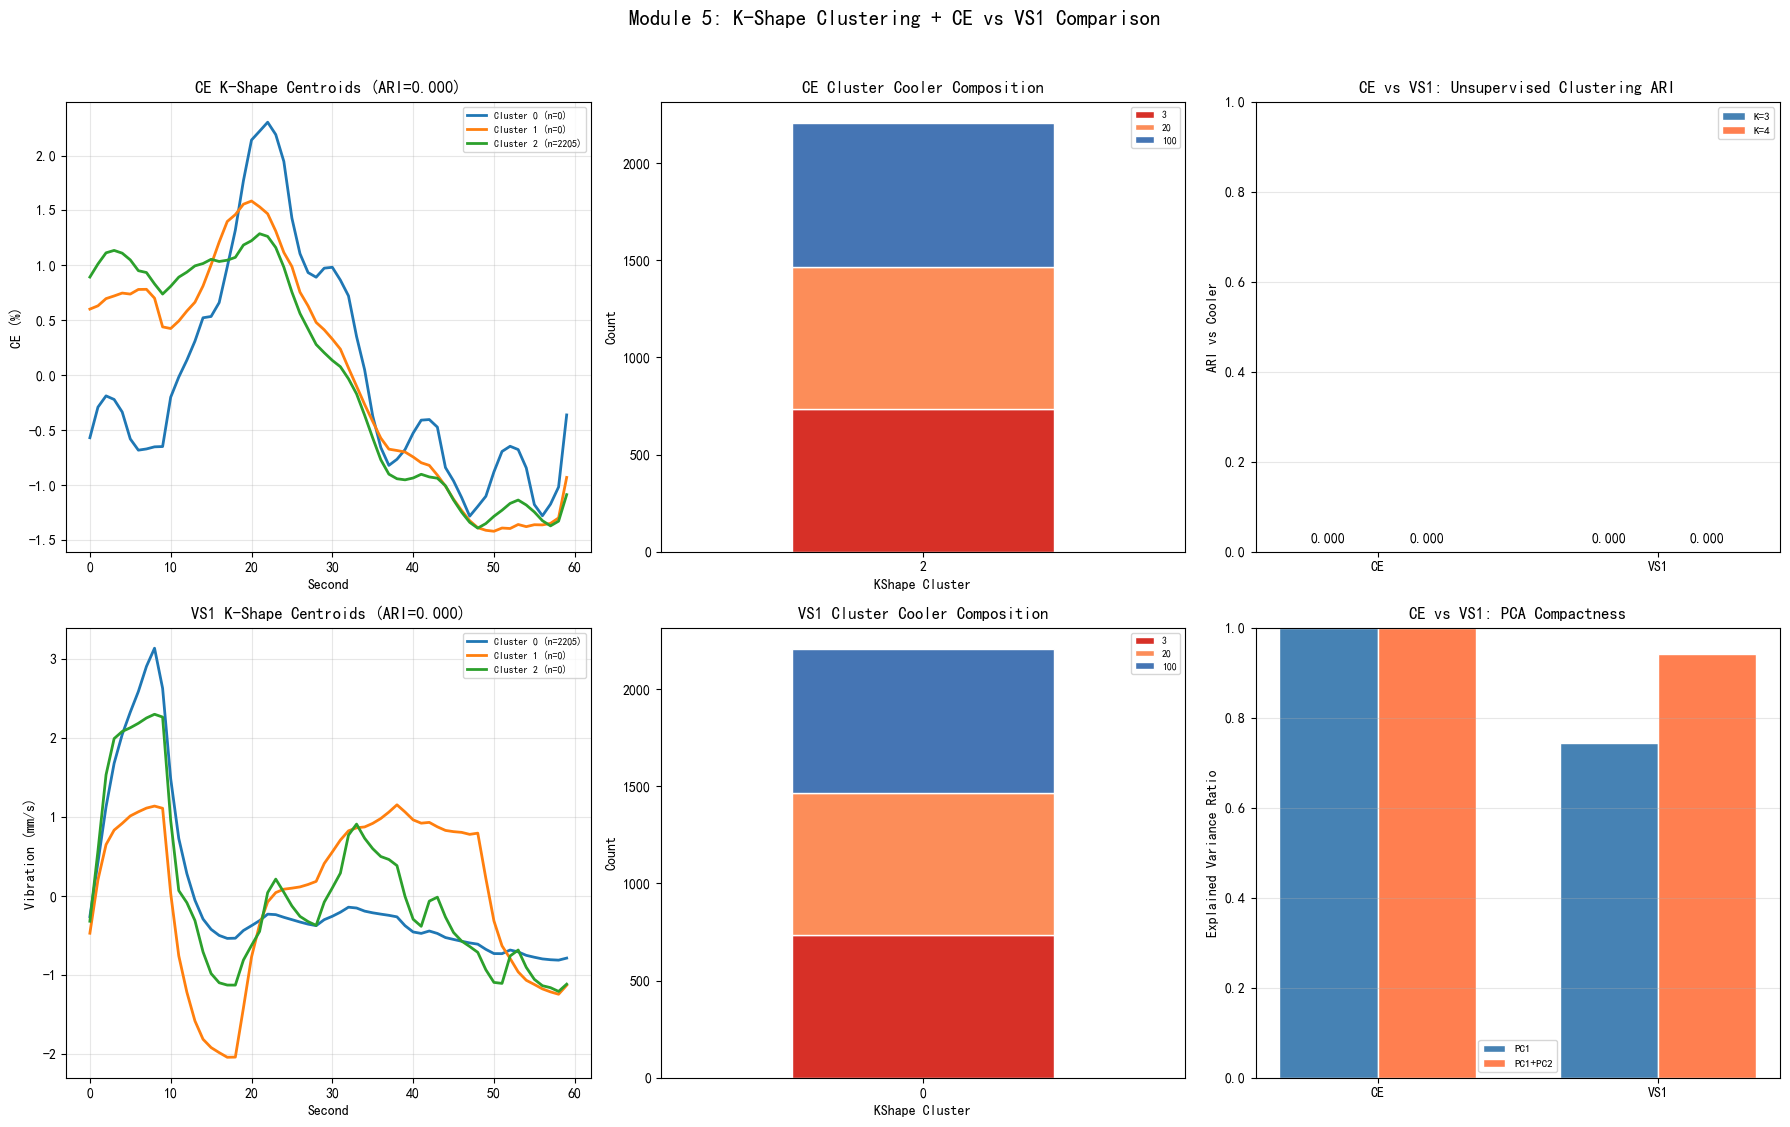

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# CE KShape centroids
for k in range(3):
    axes[0,0].plot(ks3.cluster_centers_[k], linewidth=2, label=f'Cluster {k} (n={(labels_ce_3==k).sum()})')
axes[0,0].set_title(f'CE K-Shape Centroids (ARI={ari_ce_3:.3f})', fontsize=12)
axes[0,0].set_xlabel('Second')
axes[0,0].set_ylabel('CE (%)')
axes[0,0].legend(fontsize=7)
axes[0,0].grid(True, alpha=0.3)

# VS1 KShape centroids
for k in range(3):
    axes[1,0].plot(ks_vs1_3.cluster_centers_[k], linewidth=2, label=f'Cluster {k} (n={(labels_vs1_3==k).sum()})')
axes[1,0].set_title(f'VS1 K-Shape Centroids (ARI={ari_vs1_3:.3f})', fontsize=12)
axes[1,0].set_xlabel('Second')
axes[1,0].set_ylabel('Vibration (mm/s)')
axes[1,0].legend(fontsize=7)
axes[1,0].grid(True, alpha=0.3)

# CE cluster composition
ct_ce = pd.crosstab(pd.Series(labels_ce_3, name='Cluster'), pd.Series(cooler_true, name='Cooler'))
ct_ce.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#d73027','#fc8d59','#4575b4'], edgecolor='white')
axes[0,1].set_title('CE Cluster Cooler Composition', fontsize=12)
axes[0,1].set_xlabel('KShape Cluster')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(fontsize=7)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

# VS1 cluster composition
ct_vs1 = pd.crosstab(pd.Series(labels_vs1_3, name='Cluster'), pd.Series(cooler_true, name='Cooler'))
ct_vs1.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#d73027','#fc8d59','#4575b4'], edgecolor='white')
axes[1,1].set_title('VS1 Cluster Cooler Composition', fontsize=12)
axes[1,1].set_xlabel('KShape Cluster')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(fontsize=7)
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

# ARI bar comparison
sensors = ['CE', 'VS1']
ari_vals_3 = [ari_ce_3, ari_vs1_3]
ari_vals_4 = [ari_ce_4, ari_vs1_4]
x = np.arange(len(sensors))
w = 0.35
bars1 = axes[0,2].bar(x - w/2, ari_vals_3, w, label='K=3', color='steelblue', edgecolor='white')
bars2 = axes[0,2].bar(x + w/2, ari_vals_4, w, label='K=4', color='coral', edgecolor='white')
axes[0,2].set_xticks(x)
axes[0,2].set_xticklabels(sensors)
axes[0,2].set_ylabel('ARI vs Cooler')
axes[0,2].set_title('CE vs VS1: Unsupervised Clustering ARI', fontsize=12)
axes[0,2].legend(fontsize=8)
axes[0,2].set_ylim(0, 1)
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, ari_vals_3):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=10)
for bar, val in zip(bars2, ari_vals_4):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=10)

# PCA variance comparison
pca_data = {
    'CE': [pca_ce.explained_variance_ratio_[0], sum(pca_ce.explained_variance_ratio_[:2])],
    'VS1': [pca_vs1.explained_variance_ratio_[0], sum(pca_vs1.explained_variance_ratio_[:2])]
}
x2 = np.arange(len(sensors))
w2 = 0.35
axes[1,2].bar(x2 - w2/2, [pca_data[s][0] for s in sensors], w2, label='PC1', color='steelblue', edgecolor='white')
axes[1,2].bar(x2 + w2/2, [pca_data[s][1] for s in sensors], w2, label='PC1+PC2', color='coral', edgecolor='white')
axes[1,2].set_xticks(x2)
axes[1,2].set_xticklabels(sensors)
axes[1,2].set_ylabel('Explained Variance Ratio')
axes[1,2].set_title('CE vs VS1: PCA Compactness', fontsize=12)
axes[1,2].legend(fontsize=8)
axes[1,2].set_ylim(0, 1)
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Module 5: K-Shape Clustering + CE vs VS1 Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 模块 6：CE 多故障响应 — Accumulator 交叉效应

**问题**：CE 不只对 Cooler 敏感。数据概览显示 Accumulator 也会拉低 CE。这会干扰 Cooler 诊断吗？还是 CE 可以同时监控两种故障？

In [ ]:
acc_vals = profile['Accumulator'].values
acc_states = sorted(profile['Accumulator'].unique())  # [90, 100, 115, 130]

print('=' * 60)
print('CE by Accumulator State (all Cooler conditions mixed)')
print('=' * 60)
acc_ce_stats = {}
for acc in acc_states:
    mask = acc_vals == acc
    acc_ce_stats[acc] = {
        'mean': cycle_ce_mean[mask].mean(),
        'std':  cycle_ce_mean[mask].std(),
        'n':    mask.sum()
    }
    print(f'Acc={acc:>3}bar: CE = {acc_ce_stats[acc]["mean"]:.2f}% +/- {acc_ce_stats[acc]["std"]:.2f}%  (n={acc_ce_stats[acc]["n"]})')

# F-score for Accumulator vs CE per second
f_acc = np.zeros(60)
for t in range(60):
    X_t = ce.iloc[:, t].values.reshape(-1, 1)
    f_acc[t], _ = f_classif(X_t, acc_vals)

top5_acc = sorted(np.argsort(f_acc)[-5:])
print(f'\nAccumulator top-5 discriminative seconds: {top5_acc}')
print(f'Accumulator max F = {f_acc.max():.0f}  |  Cooler max F = {f_scores_ce.max():.0f}  |  Ratio = {f_acc.max()/f_scores_ce.max():.3f}')

# Pivot table: CE mean per (Cooler, Accumulator) combination
print('\n' + '=' * 60)
print('CE Mean (%) by Cooler × Accumulator (2D pivot)')
print('=' * 60)
pivot = ce.copy()
pivot['Cooler'] = cooler_vals
pivot['Accumulator'] = acc_vals
pivot['CE_mean'] = cycle_ce_mean
table = pivot.pivot_table(values='CE_mean', index='Cooler', columns='Accumulator', aggfunc='mean')
# Also show counts
table_count = pivot.pivot_table(values='CE_mean', index='Cooler', columns='Accumulator', aggfunc='count')
print('\nMean CE (%):')
print(table.round(1).to_string())
print(f'\nSample counts:')
print(table_count.to_string())

# How much does Accumulator shift CE within a fixed Cooler state?
print('\n' + '=' * 60)
print('Accumulator effect WITHIN each Cooler state (CE range)')
print('=' * 60)
for cs in cooler_states:
    mask_c = cooler_vals == cs
    ce_range_by_acc = []
    for acc in acc_states:
        mask = mask_c & (acc_vals == acc)
        if mask.sum() >= 10:
            ce_range_by_acc.append(cycle_ce_mean[mask].mean())
    if len(ce_range_by_acc) >= 2:
        spread = max(ce_range_by_acc) - min(ce_range_by_acc)
        print(f'  Cooler={cs}%: CE spread from Accumulator variation = {spread:.2f}%')
    else:
        print(f'  Cooler={cs}%: insufficient data for Accumulator stratification')

In [ ]:
# Visualization: CE by Cooler × Accumulator + F-score comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Plot 1: CE by Accumulator state (colored by Accumulator)
acc_colors_bar = ['#4575b4','#91bfdb','#fc8d59','#d73027']
for i, acc in enumerate(acc_states):
    mask = acc_vals == acc
    axes[0].hist(cycle_ce_mean[mask], bins=40, alpha=0.5, color=acc_colors_bar[i],
                 label=f'Acc={acc}bar', edgecolor='white')
axes[0].set_xlabel('Per-cycle CE mean (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('CE Distribution by Accumulator State', fontsize=12)
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: 2D heatmap — CE by Cooler × Accumulator
# pivot_table sorts index ascending → row order is [3, 20, 100], not [100, 20, 3]
im = axes[1].imshow(table.values, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(len(acc_states)))
axes[1].set_xticklabels([f'{a}bar' for a in acc_states])
axes[1].set_yticks(range(len(table.index)))
axes[1].set_yticklabels([cooler_labels_map[s] for s in table.index])  # use pivot's actual row order
axes[1].set_title('CE Mean by Cooler × Accumulator', fontsize=12)
for i, cooler_val in enumerate(table.index):
    for j, acc_val in enumerate(table.columns):
        val = table.loc[cooler_val, acc_val]
        cnt = table_count.loc[cooler_val, acc_val]
        if not np.isnan(val):
            color = 'white' if val < 35 else 'black'
            axes[1].text(j, i, f'{val:.0f}%\nn={int(cnt)}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=axes[1], shrink=0.85)
axes[1].set_xlabel('Accumulator pressure')

# Plot 3: F-score per second — Cooler vs Accumulator
axes[2].plot(range(60), f_scores_ce / f_scores_ce.max(), 'steelblue', linewidth=2, label='F-score vs Cooler')
axes[2].plot(range(60), f_acc / f_acc.max(), 'coral', linewidth=2, linestyle='--', label='F-score vs Accumulator')
axes[2].set_xlabel('Second in cycle')
axes[2].set_ylabel('Normalized F-score')
axes[2].set_title('Per-second Discriminative Power:\nCooler vs Accumulator', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].text(55, 0.15, f'Cooler max F: {f_scores_ce.max():.0f}\nAcc max F: {f_acc.max():.0f}',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Module 6: CE Multi-Fault Response — Accumulator Cross-Sensitivity', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Key finding
acc_ce_spread = max([acc_ce_stats[a]['mean'] for a in acc_states]) - min([acc_ce_stats[a]['mean'] for a in acc_states])
print(f'\nAccumulator CE spread (all Cooler mixed): {acc_ce_spread:.1f}%')
print(f'Cooler CE spread (module 1): {ce_by_cooler[100]["mean"]-ce_by_cooler[3]["mean"]:.1f}%')
print(f'→ Cooler effect is {(ce_by_cooler[100]["mean"]-ce_by_cooler[3]["mean"])/acc_ce_spread:.0f}x larger than Accumulator effect')

---
## 模块 7：分类器验证 — CE 作为虚拟传感器的最后一公里

**问题**：前面所有分析都是定性/统计推断。能否真正训练一个分类器，用交叉验证给出 Cooler 故障诊断的**定量准确率**？

In [ ]:
# === Feature extraction ===
# From each 60-second CE curve, extract engineering features
ce_tail_mean = ce.iloc[:, 48:60].mean(axis=1).to_numpy()  # tail zone (highest F-score)
ce_range_val = ce.max(axis=1).to_numpy() - ce.min(axis=1).to_numpy()
ce_slope = np.zeros(len(ce))
for i in range(len(ce)):
    ce_slope[i] = LinearRegression().fit(np.arange(60).reshape(-1,1), ce.iloc[i].to_numpy()).coef_[0]

features = np.column_stack([
    cycle_ce_mean,           # mean CE over 60s
    cycle_ce_std,            # std within cycle
    ce_tail_mean,            # mean of last 12s (48-59s)
    ce_range_val,            # max-min within cycle
    pca_ce_scores[:, 0],     # PC1 score
    ce_slope,                # linear trend slope
])
feature_names = ['CE Mean', 'CE Std', 'CE Tail(48-59s)', 'CE Range', 'PC1 Score', 'CE Slope']
cooler_labels_ordered = [3, 20, 100]

print('=' * 60)
print('Random Forest: Cooler State Classifier (3-class)')
print('=' * 60)

# === Classifier ===
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation
cv_scores = cross_val_score(rf, features, cooler_vals, cv=skf, scoring='accuracy')
print(f'5-fold CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Individual folds: {[f"{s:.4f}" for s in cv_scores]}')

# Fit once for feature importance, use CV predictions for confusion matrix
rf.fit(features, cooler_vals)
y_pred_cv = cross_val_predict(rf, features, cooler_vals, cv=skf)

print('\n--- Feature Importance ---')
importances = rf.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = chr(0x2588) * int(imp * 50)
    print(f'  {name:<18s}: {imp:.3f} {bar}')

print('\n--- Confusion Matrix (cross-validated) ---')
cm = confusion_matrix(cooler_vals, y_pred_cv, labels=cooler_labels_ordered)
state_labels = ['Failed(3%)', 'Reduced(20%)', 'Healthy(100%)']
print(f'{"":>15s}  Predicted')
print(f'{"Actual":>15s}  {"Failed":>8s} {"Reduced":>8s} {"Healthy":>8s}')
for i, label in enumerate(state_labels):
    print(f'  {label:<13s}  {cm[i,0]:>8d} {cm[i,1]:>8d} {cm[i,2]:>8d}')
per_class_acc = np.diag(cm) / cm.sum(axis=1)
for i, label in enumerate(state_labels):
    print(f'  {label} recall: {per_class_acc[i]:.4f}')

# === Minimal classifier: CE mean alone ===
rf_simple = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4)
cv_simple = cross_val_score(rf_simple, cycle_ce_mean.reshape(-1, 1), cooler_vals,
                            cv=skf, scoring='accuracy')
print(f'\n--- Minimal Model ---')
print(f'RF with CE Mean only: {cv_simple.mean():.4f} +/- {cv_simple.std():.4f}')

# Threshold-based rule accuracy
threshold_pred = np.ones_like(cooler_vals) * 100  # default healthy
threshold_pred[cycle_ce_mean < 35.0] = 20           # reduced
threshold_pred[cycle_ce_mean < 23.0] = 3            # near-failure
threshold_acc = (threshold_pred == cooler_vals).mean()
print(f'Simple threshold rule (CE<35%→Reduced, CE<23%→Failed): {threshold_acc:.4f}')

---
## 五维度结论速查表

In [ ]:
print()
print('=' * 70)
print('CE Cooling Efficiency Deep Analysis — Summary')
print('=' * 70)
print()
print('1. CE-Cooler Dose-Response:')
print(f'   Cooler 100% -> CE = {ce_by_cooler[100]["mean"]:.1f}%')
print(f'   Cooler 20%  -> CE = {ce_by_cooler[20]["mean"]:.1f}%')
print(f'   Cooler 3%   -> CE = {ce_by_cooler[3]["mean"]:.1f}%')
print(f'   Separation: Cohen d(100vs20)={(ce_by_cooler[100]["mean"]-ce_by_cooler[20]["mean"])/np.sqrt((ce_by_cooler[100]["std"]**2+ce_by_cooler[20]["std"]**2)/2):.1f}, '
      f'd(20vs3)={(ce_by_cooler[20]["mean"]-ce_by_cooler[3]["mean"])/np.sqrt((ce_by_cooler[20]["std"]**2+ce_by_cooler[3]["std"]**2)/2):.1f}')
print(f'   Outliers: {outlier_mask.sum()} cycles deviate from group median by >{threshold:.1f}%')
print()
print('2. Intra-cycle Dynamics:')
print(f'   CE slowly decreases during cycle; all Cooler states share same shape')
print(f'   Degradation signal strongest in cycle tail (48-59s, F-score > 350k)')
print()
print('3. PCA + Information Density:')
print(f'   CE  PC1 explains {pca_ce.explained_variance_ratio_[0]:.1%} (VS1: {pca_vs1.explained_variance_ratio_[0]:.1%})')
print(f'   CE is essentially 1D: a single scalar captures all Cooler-discriminative info')
print()
print('4. State-switch Response:')
print(f'   Only {len(transitions)} transitions — CE jumps instantly (>8%), confirming step-function behavior')
print()
print('5. Shape Clustering:')
print(f'   CE  K-Shape ARI = {ari_ce_3:.4f}  |  VS1 K-Shape ARI = {ari_vs1_3:.4f}')
print(f'   -> Both fail: fault info is in CE level, not shape')
print()
print('6. Multi-Fault Response:')
cooler_spread = ce_by_cooler[100]["mean"]-ce_by_cooler[3]["mean"]
acc_spread = max([acc_ce_stats[a]['mean'] for a in acc_states]) - min([acc_ce_stats[a]['mean'] for a in acc_states])
print(f'   Cooler CE spread = {cooler_spread:.1f}%  |  Accumulator CE spread = {acc_spread:.1f}%')
print(f'   Cooler effect is {cooler_spread/acc_spread:.0f}x stronger than Accumulator')
print(f'   Accumulator=130bar can mimic Cooler=20% (CE ~27% in both cases) — needs awareness')
print()
print('7. Classifier Validation:')
print(f'   RF 5-fold CV accuracy = {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'   RF with CE Mean only     = {cv_simple.mean():.4f}')
print(f'   Simple threshold rule    = {threshold_acc:.4f}')
print(f'   -> CE is a production-ready virtual sensor for Cooler health')
print()
print('=' * 70)
print('CE Analysis Complete.')